<a href="https://colab.research.google.com/github/Vivekshrotriya1/Capgemini-Training/blob/main/Day13DBScan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [ ]:
X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

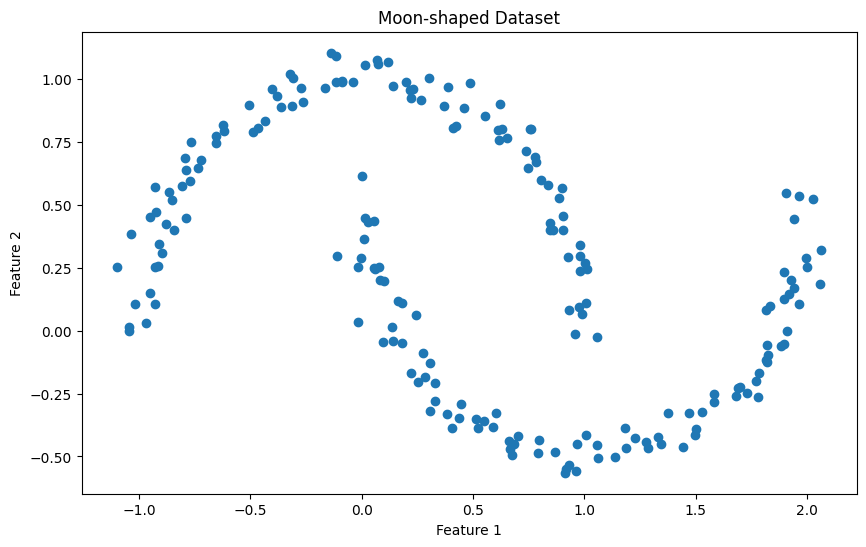

In [ ]:
# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

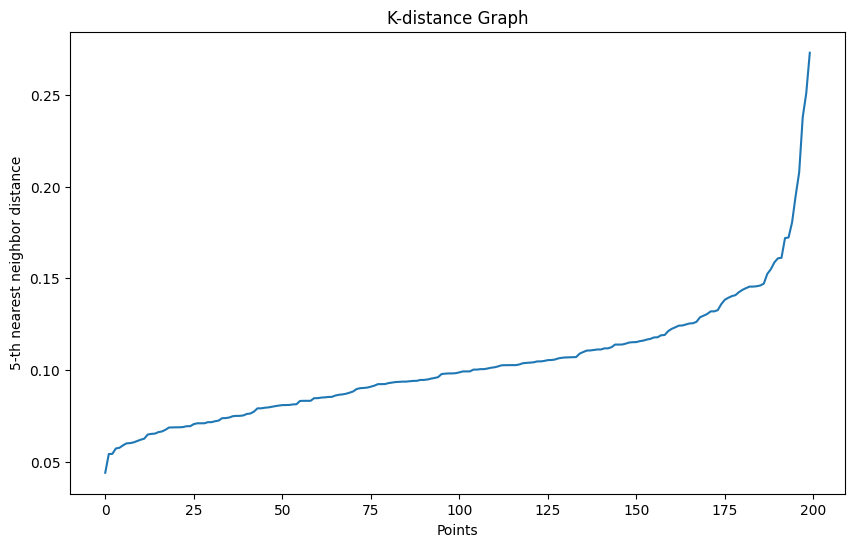

In [ ]:
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

#Scenario:
 Customer Segmentation for a Retail Store
Context:
A retail store wants to understand its customers better. They have data on how much each customer spends per visit and how frequently they visit the store. The goal is to group customers into clusters (e.g., “loyal high spenders,” “occasional visitors,” etc.) using DBSCAN, which is great for finding clusters of varying shapes and identifying outliers.

Cluster Labels: [ 0  0  0  1  1  1  2  2  2 -1  1]


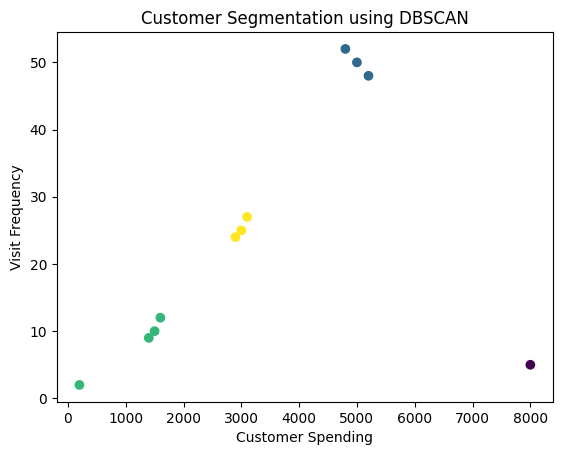

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier: rare but huge spender
    [200, 2]                              # Outlier: very low engagement
])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=2)
labels = dbscan.fit_predict(data_scaled)

print("Cluster Labels:", labels)
plt.scatter(data[:,0], data[:,1], c=labels)

plt.xlabel("Customer Spending")
plt.ylabel("Visit Frequency")
plt.title("Customer Segmentation using DBSCAN")

plt.show()

#Scenario:
Fine‑tune ResNet‑50 for Music Genre Classification
Context:
A streaming service wants to automatically classify songs into genres (e.g., rock, jazz, classical, hip‑hop, electronic). They have 4,000 audio tracks labeled by genre. Instead of training from scratch, they’ll fine‑tune a ResNet‑50 pretrained on ImageNet, but adapted to work with spectrogram images of audio.

📊 Dataset
- Convert each audio track into a Mel‑spectrogram (visual representation of sound frequencies over time).
- Each spectrogram is treated like an image (RGB channels).
- Dataset: 4,000 spectrograms across 5 genres.

In [ ]:
from google.colab import files
uploaded =files.upload()

Saving music_spectrograms_sample_dataset.zip to music_spectrograms_sample_dataset.zip


In [ ]:
!unzip music_spectrograms_sample_dataset.zip


Archive:  music_spectrograms_sample_dataset.zip
  inflating: music_spectrograms/rock/rock_1.png  
  inflating: music_spectrograms/rock/rock_2.png  
  inflating: music_spectrograms/rock/rock_3.png  
  inflating: music_spectrograms/rock/rock_4.png  
  inflating: music_spectrograms/rock/rock_5.png  
  inflating: music_spectrograms/jazz/jazz_1.png  
  inflating: music_spectrograms/jazz/jazz_2.png  
  inflating: music_spectrograms/jazz/jazz_3.png  
  inflating: music_spectrograms/jazz/jazz_4.png  
  inflating: music_spectrograms/jazz/jazz_5.png  
  inflating: music_spectrograms/classical/classical_1.png  
  inflating: music_spectrograms/classical/classical_2.png  
  inflating: music_spectrograms/classical/classical_3.png  
  inflating: music_spectrograms/classical/classical_4.png  
  inflating: music_spectrograms/classical/classical_5.png  
  inflating: music_spectrograms/hiphop/hiphop_1.png  
  inflating: music_spectrograms/hiphop/hiphop_2.png  
  inflating: music_spectrograms/hiphop/hipho

In [ ]:

import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader



transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])




dataset = ImageFolder(
    root="music_spectrograms",
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("Classes:", dataset.classes)


model = models.resnet50(weights="IMAGENET1K_V2")



for param in model.parameters():
    param.requires_grad = False



num_classes = 5

model.fc = nn.Sequential(

    nn.Dropout(0.4),

    nn.Linear(model.fc.in_features,256),

    nn.ReLU(),

    nn.Linear(256,num_classes)
)



for param in model.layer4.parameters():
    param.requires_grad = True




optimizer = torch.optim.Adam([

    {'params': model.layer4.parameters(), 'lr':1e-4},

    {'params': model.fc.parameters(), 'lr':1e-3}
])




criterion = nn.CrossEntropyLoss()




epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for images, labels in dataloader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    print("Epoch:", epoch+1, "Loss:", total_loss)

Classes: ['classical', 'electronic', 'hiphop', 'jazz', 'rock']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s]


Epoch: 1 Loss: 11.829269886016846
Epoch: 2 Loss: 10.74552595615387
Epoch: 3 Loss: 9.769882559776306
Epoch: 4 Loss: 8.217393457889557
Epoch: 5 Loss: 6.248153984546661


#Scenario:
 Medical Image Classification
You’re training a convolutional neural network (CNN) to detect pneumonia from chest X-rays.
- Training accuracy: 95%
- Validation accuracy: 74%
At first glance, the model seems powerful — it almost perfectly classifies the training set. But the sharp drop in validation accuracy signals overfitting: the network has memorized the training images (specific pixel patterns, noise, or even hospital-specific artifacts) instead of learning generalizable features of pneumonia.

⚙️ Levers to Address Overfitting
- Data Augmentation: Rotate, flip, and adjust brightness of X-rays to simulate variability.
- Regularization: Apply dropout in dense layers or L2 weight decay.
- Transfer Learning: Use a pretrained backbone (e.g., ResNet) to leverage generalized features.
- Cross-validation: Ensure robustness across different patient subsets.
- Early Stopping: Halt training when validation loss stops improving.

In [ ]:
from google.colab import files
uploaded =files.upload()

!unzip sample_pneumonia_xray_datasetDay


import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")




train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])




val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])



transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = ImageFolder("pneumonia_dataset/train", transform=train_transform)
val_dataset = ImageFolder("pneumonia_dataset/val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

print("Classes:", train_dataset.classes)




model = models.resnet18(weights="IMAGENET1K_V1")


# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False



model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 2)
)

model = model.to(device)




criterion = nn.CrossEntropyLoss()




optimizer = Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)




best_val_loss = float('inf')
patience = 3
counter = 0



epochs = 20

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()


    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()


    print(f"Epoch {epoch+1}")
    print("Training Loss:", train_loss)
    print("Validation Loss:", val_loss)




    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")

    else:

        counter += 1

        if counter >= patience:

            print("Early stopping triggered")
            break

Saving sample_pneumonia_xray_dataset.zip to sample_pneumonia_xray_dataset (1).zip
unzip:  cannot find or open sample_pneumonia_xray_datasetDay, sample_pneumonia_xray_datasetDay.zip or sample_pneumonia_xray_datasetDay.ZIP.
Classes: ['normal', 'pneumonia']
Epoch 1
Training Loss: 4.52926629781723
Validation Loss: 1.7384234070777893
Epoch 2
Training Loss: 3.2357060313224792
Validation Loss: 2.088249072432518
Epoch 3
Training Loss: 3.394644320011139
Validation Loss: 2.2500218600034714
Epoch 4
Training Loss: 5.1594114899635315
Validation Loss: 2.4435373842716217
Early stopping triggered
